# GRAFO DE RELACIONES ENTRE PARTICIPANTES DEL 23F

### Instalar librerías requeridas para el análisis

In [ ]:
!jupyter nbconvert --to markdown Relaciones_23F_v1_4.ipynb

[NbConvertApp] Converting notebook Relaciones_23F_v1_4.ipynb to markdown
[NbConvertApp] Support files will be in Relaciones_23F_v1_4_files/
[NbConvertApp] Making directory Relaciones_23F_v1_4_files
[NbConvertApp] Writing 42686 bytes to Relaciones_23F_v1_4.md


In [1]:
# Install Libraries
!pip install spacy
!pip install altair
!pip install sentence-transformers
!pip install gensim
!python -m spacy download es_core_news_lg
!pip install networkx pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 50.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.0/568.0 MB 1.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 90.9 MB/s eta 0:00:00


In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp
from sentence_transformers import SentenceTransformer
import numpy as np
import requests
from lxml import html
from tqdm import tqdm
import os
import hashlib
import spacy
import gensim
import nltk
import altair as alt
from collections import defaultdict

### Carga de documentos scrapeados

In [2]:
from google.colab import files
files.upload()

Saving 23f_scrappedDF_v02.csv to 23f_scrappedDF_v02.csv


{'23f_scrappedDF_v02.csv': b'\xef\xbb\xbftitle,url,pages,summary,tags,transcript,filename\nVista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,https://23fbuscador.rtve.es/document/ocr/1860,3,"El juicio oral 2/81 celebrado en febrero de 1982 se caracteriz\xc3\xb3 por un intenso desarrollo en sus primeras sesiones, con declaraciones parciales de altos mandos militares y certificaciones oficiales, aunque plagado de controversias por la interpretaci\xc3\xb3n y selecci\xc3\xb3n de testimonios, especialmente en relaci\xc3\xb3n con figuras clave como el Teniente Coronel Tejero y autoridades civiles. Surgieron tensiones notables entre la Fiscal\xc3\xada y la defensa, vinculadas a la lectura fragmentada de declaraciones y a cuestionamientos sobre el papel de la Corona. Adem\xc3\xa1s, se evidenci\xc3\xb3 la implicaci\xc3\xb3n del CESID, particularmente del Sector de Valencia y posibles m\xc3\xa1s miembros relacionados, junto con una creciente participaci\xc3\xb3n de 

In [3]:
df = pd.read_csv('23f_scrappedDF_v02.csv')

In [4]:
df.head(1)

,title,url,pages,summary,tags,transcript,filename
0,Vista oral 2/81 del Consejo Supremo de Justici...,https://23fbuscador.rtve.es/document/ocr/1860,3,El juicio oral 2/81 celebrado en febrero de 19...,No consta||Luis Arana Lorite:Teniente Coronel|...,C/SG/2820/20-02-82\nDTOR.\n\nNOTA INFORMATIVA\...,Vista oral 281 del Consejo Supremo de Justicia...


## 1. Análisis Estadístico - Dataframe 23F


In [5]:
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
print("\nTipos de dato:")
print(df.dtypes)
print("\nValores nulos:")
print(df.isnull().sum())
print("\nEjemplo de transcript:")
print(df['transcript'][0][:500])

Filas: 167 | Columnas: 7

Tipos de dato:
title         object
url           object
pages          int64
summary       object
tags          object
transcript    object
filename      object
dtype: object

Valores nulos:
title         0
url           0
pages         0
summary       0
tags          0
transcript    0
filename      0
dtype: int64

Ejemplo de transcript:
C/SG/2820/20-02-82
DTOR.

NOTA INFORMATIVA

ASUNTO: Vista oral 2/81

1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82

- Solo ha tenido lugar la sesión de la mañana. Empezó a las 10,06 horas.

- Durante la sesión han tenido lugar, a petición del Sr. Fiscal las declaraciones siguientes:

. Parcial de Teniente Coronel D. Luis Arana Lorite (Ayte. Gral. Lluch).

. Parcial de Teniente Coronel D. Manuel Miler Hidalgo (Ayte. Gral. Esquivias).

. 1ª, 2ª, 3ª y 4ª del Teniente Coronel TEJERO.

. Ca


In [6]:
print(df['transcript'][0])

C/SG/2820/20-02-82
DTOR.

NOTA INFORMATIVA

ASUNTO: Vista oral 2/81

1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82

- Solo ha tenido lugar la sesión de la mañana. Empezó a las 10,06 horas.

- Durante la sesión han tenido lugar, a petición del Sr. Fiscal las declaraciones siguientes:

. Parcial de Teniente Coronel D. Luis Arana Lorite (Ayte. Gral. Lluch).

. Parcial de Teniente Coronel D. Manuel Miler Hidalgo (Ayte. Gral. Esquivias).

. 1ª, 2ª, 3ª y 4ª del Teniente Coronel TEJERO.

. Careo Teniente Coronel TEJERO - SR. CARRES.

- Descanso de 11,50 horas a 12,13 horas.

. Careo Teniente Coronel TEJERO - Capitán GOMEZ IGLESIAS

. Certificación del Presidente del Congreso Sr. LAVILLA.

. Certificación sobre la situación militar del TCOL.TEJERO.

. 1ª y 3ª del Coronel D. DIEGO IBAÑEZ INGLES

. Certificación del entonces Gobernador Civil de Valencia D.José María Fernández del Rio Fernández

. 1ª y 3ª del Teniente Coronel MAS OLIVER.

La vista se interrumpió hasta las 10,00 horas de

In [ ]:
df.head(1)

## 2. Limpieza Basica usando spaCy

In [7]:
# Carga el modelo español grande
nlp = spacy.load("es_core_news_lg")

# Verifica que cargó correctamente
print(nlp.pipe_names)  # ['tok2vec', 'morphologizer', 'parser', 'ner', ...]

['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


In [8]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', text)  # control chars
    text = re.sub(r'\n+', ' ', text) # Elimina saltos de línea
    text = re.sub(r'\s+', ' ', text) # Colapsa espacios múltiples
    text = re.sub(r'[^\w\s.,;:áéíóúüñÁÉÍÓÚÜÑ]', '', text) # Conserva puntuación básica y tildes
    return text.strip()

In [9]:
df['transcript_clean'] = df['transcript'].apply(clean_text)

In [10]:
df['transcript_clean'][0]

'CSG2820200282 DTOR. NOTA INFORMATIVA ASUNTO: Vista oral 281 1. DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 200282  Solo ha tenido lugar la sesión de la mañana. Empezó a las 10,06 horas.  Durante la sesión han tenido lugar, a petición del Sr. Fiscal las declaraciones siguientes: . Parcial de Teniente Coronel D. Luis Arana Lorite Ayte. Gral. Lluch. . Parcial de Teniente Coronel D. Manuel Miler Hidalgo Ayte. Gral. Esquivias. . 1ª, 2ª, 3ª y 4ª del Teniente Coronel TEJERO. . Careo Teniente Coronel TEJERO  SR. CARRES.  Descanso de 11,50 horas a 12,13 horas. . Careo Teniente Coronel TEJERO  Capitán GOMEZ IGLESIAS . Certificación del Presidente del Congreso Sr. LAVILLA. . Certificación sobre la situación militar del TCOL.TEJERO. . 1ª y 3ª del Coronel D. DIEGO IBAÑEZ INGLES . Certificación del entonces Gobernador Civil de Valencia D.José María Fernández del Rio Fernández . 1ª y 3ª del Teniente Coronel MAS OLIVER. La vista se interrumpió hasta las 10,00 horas del lunes día 220282. 1 .. 2. INCIDE

###Procesamiento linguistico por batches con spaCy

In [11]:
# batch_size=32 es un buen punto de partida; auméntalo si tienes RAM suficiente
docs = list(nlp.pipe(df['transcript_clean'], batch_size=32))

# Guarda los objetos Doc en el DataFrame para reutilizarlos
df['spacy_doc'] = docs

In [12]:
df['spacy_doc'][0]

CSG2820200282 DTOR. NOTA INFORMATIVA ASUNTO: Vista oral 281 1. DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 200282  Solo ha tenido lugar la sesión de la mañana. Empezó a las 10,06 horas.  Durante la sesión han tenido lugar, a petición del Sr. Fiscal las declaraciones siguientes: . Parcial de Teniente Coronel D. Luis Arana Lorite Ayte. Gral. Lluch. . Parcial de Teniente Coronel D. Manuel Miler Hidalgo Ayte. Gral. Esquivias. . 1ª, 2ª, 3ª y 4ª del Teniente Coronel TEJERO. . Careo Teniente Coronel TEJERO  SR. CARRES.  Descanso de 11,50 horas a 12,13 horas. . Careo Teniente Coronel TEJERO  Capitán GOMEZ IGLESIAS . Certificación del Presidente del Congreso Sr. LAVILLA. . Certificación sobre la situación militar del TCOL.TEJERO. . 1ª y 3ª del Coronel D. DIEGO IBAÑEZ INGLES . Certificación del entonces Gobernador Civil de Valencia D.José María Fernández del Rio Fernández . 1ª y 3ª del Teniente Coronel MAS OLIVER. La vista se interrumpió hasta las 10,00 horas del lunes día 220282. 1 .. 2. INCIDEN

## 3. Extracción de Features Linguisticos

In [13]:
def extract_features(doc):
    return {
        "tokens": [token.text for token in doc if not token.is_stop and not token.is_punct],
        "lemmas": [token.lemma_ for token in doc if not token.is_stop and not token.is_punct],
        "entities": [(ent.text, ent.label_) for ent in doc.ents],
        "sentences": [sent.text for sent in doc.sents]
    }

df['nlp_features'] = df['spacy_doc'].apply(extract_features)

In [14]:
df['nlp_features'][0]

{'tokens': ['CSG2820200282',
  'DTOR',
  'NOTA',
  'INFORMATIVA',
  'ASUNTO',
  'Vista',
  'oral',
  '281',
  '1',
  'DESARROLLO',
  'SESIÓN',
  'CORRESPONDIENTE',
  '200282',
  ' ',
  'lugar',
  'sesión',
  'mañana',
  'Empezó',
  '10,06',
  'horas',
  ' ',
  'sesión',
  'lugar',
  'petición',
  'Sr.',
  'Fiscal',
  'declaraciones',
  'siguientes',
  'Parcial',
  'Teniente',
  'Coronel',
  'D.',
  'Luis',
  'Arana',
  'Lorite',
  'Ayte',
  'Gral.',
  'Lluch',
  'Parcial',
  'Teniente',
  'Coronel',
  'D.',
  'Manuel',
  'Miler',
  'Hidalgo',
  'Ayte',
  'Gral.',
  'Esquivias',
  '1ª',
  '2ª',
  '3ª',
  '4ª',
  'Teniente',
  'Coronel',
  'TEJERO',
  'Careo',
  'Teniente',
  'Coronel',
  'TEJERO',
  ' ',
  'SR',
  'CARRES',
  ' ',
  'Descanso',
  '11,50',
  'horas',
  '12,13',
  'horas',
  'Careo',
  'Teniente',
  'Coronel',
  'TEJERO',
  ' ',
  'Capitán',
  'GOMEZ',
  'IGLESIAS',
  'Certificación',
  'Presidente',
  'Congreso',
  'Sr.',
  'LAVILLA',
  'Certificación',
  'situación',
  

### Aplicacion de Named Entities Recognition (NER)

In [15]:
# Tipos de entidad relevantes para el análisis del 23-F
ENTITY_TYPES = {
    "PER": "Persona",
    "LOC": "Lugar",
    "ORG": "Organización"
}

# Cargar modelo (reutilizar si ya está en memoria desde Fase 0)
nlp = spacy.load("es_core_news_lg")

print(f"Modelo cargado: {nlp.meta['name']} v{nlp.meta['version']}")
print(f"Componentes activos: {nlp.pipe_names}")
print(f"Tipos de entidad a extraer: {list(ENTITY_TYPES.keys())}")

Modelo cargado: core_news_lg v3.8.0
Componentes activos: ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']
Tipos de entidad a extraer: ['PER', 'LOC', 'ORG']


### Identificación de Entidades Nombradas en el Texto Normalizado

In [16]:
# Prefijos de rango/tratamiento ordenados de mayor a menor longitud
RANK_PREFIXES = sorted([
    "teniente coronel", "teniente general", "capitán general",
    "teniente", "general", "coronel", "capitán", "comandante",
    "almirante", "sargento", "cabo 1º", "cabo 12", "cabo",
    "gral.", "gral", "tcol.", "tcol", "tte.", "tte", "cte.", "cte",
    "cap.", "cap", "sgto.", "sgto",
    "sr. don", "sr. d.", "sr.", "don", "doña", "d.",
    "señor", "señora", "el", "la",
], key=len, reverse=True)

def strip_rank_prefix(name: str) -> str:
    """
    Elimina prefijos de rango/tratamiento para obtener el nombre canónico.
    'coronel tejero'         → 'tejero'
    'teniente coronel tejero'→ 'tejero'
    'sr. don antonio tejero' → 'antonio tejero'
    'carmen tejero'          → 'carmen tejero'  (sin cambio, no hay prefijo)
    """
    changed = True
    while changed:
        changed = False
        name_lower = name.lower()
        for prefix in RANK_PREFIXES:
            if name_lower.startswith(prefix + " "):
                name = name[len(prefix):].strip()
                name_lower = name.lower()
                changed = True
                break
        # Evitar que el resultado caiga en el blocklist
        if name.lower() in ENTITY_BLOCKLIST:
            return ""   # descartará la entidad al hacer el filtro
    return name

def merge_suffix_variants(entity_set: set) -> set:
    """
    Fusiona variantes de nombre dentro del mismo documento.
    Si A es sufijo de B (misma clase), A es redundante → se elimina.

    {'tejero', 'antonio tejero', 'carmen tejero'}
      → 'tejero' es sufijo de 'antonio tejero' Y de 'carmen tejero'
      → resultado: {'antonio tejero', 'carmen tejero'}

    {'armada', 'alfonso armada'}
      → 'armada' es sufijo de 'alfonso armada'
      → resultado: {'alfonso armada'}
    """
    to_remove = set()
    entity_list = list(entity_set)
    for e_short in entity_list:
        for e_long in entity_list:
            if e_short != e_long and e_long.endswith(" " + e_short):
                to_remove.add(e_short)
                break
    return entity_set - to_remove

In [17]:
GLOBAL_CANONICAL_MAP = {
    "milans": "jaime milans del bosch",
    "milans del bosch": "jaime milans del bosch",
    "tejero": "antonio tejero",
    "tejero molina": "antonio tejero",
    "armada": "alfonso armada",
    "general armada": "alfonso armada",
    "gral armada": "alfonso armada",
    "suárez": "adolfo suárez",
    "calvo sotelo": "leopoldo calvo sotelo",
    "gutiérrez mellado": "manuel gutiérrez mellado",
    "fernández campos": "sabino fernández campos",
    "aramburu": "josé aramburu topete",
    "gabeiras": "josé gabeiras"
}

def canonicalize_entity(name: str) -> str:
    name_clean = name.strip().lower()
    return GLOBAL_CANONICAL_MAP.get(name_clean, name_clean)

In [18]:
texts = df["transcript_clean"].tolist()
total_docs = len(texts)
BATCH_SIZE = 8

print(f"Procesando {total_docs} documentos con NER (batch_size={BATCH_SIZE})...")

# nlp.pipe() devuelve un generador, tqdm lo envuelve sin romper el batch interno
docs = []

with tqdm(
    nlp.pipe(texts, batch_size=BATCH_SIZE),
    total=total_docs,
    desc="NER Fase 1",
    unit="doc",
    bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} docs [{elapsed}<{remaining}, {rate_fmt}]"
) as pbar:
    for doc in pbar:
        docs.append(doc)

        # Actualiza el postfix cada BATCH_SIZE documentos para no saturar la UI
        if len(docs) % BATCH_SIZE == 0:
            ents_so_far = sum(
                1 for d in docs for e in d.ents if e.label_ in ENTITY_TYPES
            )
            pbar.set_postfix({
                "entidades": ents_so_far,
                "batch": f"{len(docs) // BATCH_SIZE}/{-(-total_docs // BATCH_SIZE)}"  # ceil division
            })

print(f"\nCompletado. {len(docs)} documentos procesados.")
print(f"Total entidades encontradas: {sum(1 for d in docs for e in d.ents if e.label_ in ENTITY_TYPES)}")

Procesando 167 documentos con NER (batch_size=8)...


NER Fase 1: 100%|██████████| 167/167 docs [00:58<00:00,  2.87doc/s]


Completado. 167 documentos procesados.
Total entidades encontradas: 20828


## 4. Generacion del DataFrame de Entidades Nombradas

### Identificación y Filtrado de Entidades con base en Tipología de SpaCy

In [46]:
# Palabras que nunca son entidades válidas solas
ENTITY_BLOCKLIST = {
    "general", "generales", "teniente", "tenientes", "coronel", "coroneles",
    "capitán", "capitanes", "comandante", "comandantes", "almirante",
    "sargento", "sargentos", "cabo", "subteniente",
    "incidencias", "actuaciones", "situaciones", "desarrollo",
    "militares", "policías", "guardias", "funcionarios",
    "desarrollo de", "situaciones de", "actuaciones de",
}

# Patrón de artefacto de diálogo: letra/abrev. + espacios = etiqueta de interlocutor
# Captura: "a  buenas", "b  sí", "g.c. hijo", "t. armada"
DIALOGUE_ARTIFACT_RE = re.compile(r'^[a-z]\.?\s{1,3}\S')

# Detecta strings con dígitos mezclados con letras (códigos de documento)
CODE_PATTERN = re.compile(r'\d{3,}')  # 3+ dígitos consecutivos = código

def is_valid_entity(ent) -> bool:
    tokens = [token for token in ent]
    text   = ent.text.strip()
    text_l = text.lower()

    # NUEVA Regla 1: rechazar artefactos de diálogo (etiquetas de interlocutor)
    if DIALOGUE_ARTIFACT_RE.match(text_l):
        return False

    # NUEVA Regla 2: rechazar palabras en el blocklist (rangos solos, genéricos)
    if text_l in ENTITY_BLOCKLIST or text_l.rstrip('.') in ENTITY_BLOCKLIST:
        return False

    # Regla 3: al menos un token debe ser PROPN o NOUN
    if not any(t.pos_ in ("PROPN", "NOUN") for t in tokens):
        return False

    # Regla 4: no puede ser solo ADJ, ADV, VERB o DET
    if all(t.pos_ in ("ADJ", "ADV", "VERB", "DET") for t in tokens):
        return False

    # Regla 5: longitud mínima
    if len(text) <= 2:
        return False

    # Regla 6: rechazar códigos con dígitos
    if CODE_PATTERN.search(text):
        return False

    # Regla 7: rechazar frases largas
    if len(tokens) > 5:
        return False

    # Regla 8: rechazar si contiene VERB
    if any(t.pos_ == "VERB" for t in tokens):
        return False

    # Regla 9: rechazar si contiene artículos o preposiciones internas
    internal_tokens = tokens[1:-1]
    if any(t.pos_ in ("DET", "ADP") for t in internal_tokens):
        return False

    # NUEVA Regla 10 Optimizada: PER debe tener 1 PROPN, excepto si es un apellido clave del 23F
    # Bloquea sustantivos comunes que spaCy etiqueta PER (e.g. "incidencias")
    apellidos_criticos = {"tejero", "milans", "armada", "suárez", "gabeiras", "cortina", "mellado"}
    if ent.label_ == "PER" and not any(t.pos_ == "PROPN" for t in tokens):
      if not any(ap in text_l for ap in apellidos_criticos):
          return False

    return True

In [47]:
# --- Estructura 1: entidades agregadas por documento ---
entity_records = []

for idx, (doc_idx, row) in enumerate(df.iterrows()):
    doc = docs[idx]
    entities = defaultdict(set)

    for ent in doc.ents:
        if ent.label_ in ENTITY_TYPES and is_valid_entity(ent):  # <-- filtro aplicado
            normalized = canonicalize_entity(strip_rank_prefix(ent.text.strip().lower()))
            if normalized:                          # strip_rank_prefix devuelve "" si cae en blocklist
              entities[ent.label_].add(normalized)

    # Fusionar variantes de sufijo dentro del documento
    for label in list(entities.keys()):
      entities[label] = merge_suffix_variants(entities[label])

    entity_records.append({
        "doc_id":          row.get("doc_id", doc_idx),
        "persons":         sorted(list(entities.get("PER", []))),
        "locations":       sorted(list(entities.get("LOC", []))),
        "organizations":   sorted(list(entities.get("ORG", []))),
        "n_persons":       len(entities.get("PER", [])),
        "n_locations":     len(entities.get("LOC", [])),
        "n_organizations": len(entities.get("ORG", []))
    })

df_entities = pd.DataFrame(entity_records)

df_entities["total_entities"] = (
    df_entities["n_persons"] +
    df_entities["n_locations"] +
    df_entities["n_organizations"]
)

# --- Estructura 2: registro plano de menciones ---
mention_records = []

for idx, (doc_idx, row) in enumerate(df.iterrows()):
    doc = docs[idx]
    doc_id = row.get("doc_id", doc_idx)

    for ent in doc.ents:
        if ent.label_ in ENTITY_TYPES and is_valid_entity(ent):  # <-- filtro aplicado
            normalized = canonicalize_entity(strip_rank_prefix(ent.text.strip().lower()))
            if not normalized:
              continue                            # saltar entidades que quedaron vacías
            ctx_start = max(0, ent.start - 5)
            ctx_end   = min(len(doc), ent.end + 5)

            mention_records.append({
                "doc_id":      doc_id,
                "entity_raw":  ent.text.strip(),
                "entity_norm": normalized,
                "label":       ent.label_,
                "label_desc":  ENTITY_TYPES[ent.label_],
                "context":     doc[ctx_start:ctx_end].text
            })

df_mentions = pd.DataFrame(mention_records)

print(f"df_entities shape: {df_entities.shape}")
print(f"df_mentions shape: {df_mentions.shape}")
print(f"\nTotal menciones por tipo:\n{df_mentions['label'].value_counts()}")

df_entities shape: (167, 8)
df_mentions shape: (14404, 6)

Total menciones por tipo:
label
PER    5682
ORG    4875
LOC    3847
Name: count, dtype: int64


In [48]:
# Entidades a inyectar manualmente por documento
MANUAL_INJECTIONS = [
    {"doc_id": 61, "entity_raw": "Consejo de Guerra", "entity_norm": "consejo de guerra", "label": "ORG"},
    # Añade más filas aquí si aparecen casos similares en otros docs
]

for inj in MANUAL_INJECTIONS:
    inj["label_desc"]     = ENTITY_TYPES.get(inj["label"], inj["label"])
    inj["context"]        = ""
    inj["label_resolved"] = inj["label"]

df_injections = pd.DataFrame(MANUAL_INJECTIONS)
df_mentions   = pd.concat([df_mentions, df_injections], ignore_index=True)

print(f"Inyecciones aplicadas: {len(MANUAL_INJECTIONS)}")
print(df_mentions[df_mentions["doc_id"] == 61])

Inyecciones aplicadas: 1
       doc_id         entity_raw        entity_norm label    label_desc  \
14404      61  Consejo de Guerra  consejo de guerra   ORG  Organización   

      context label_resolved  
14404                    ORG  


## 5. Revisión de Calidad de Entidades Identificadas

In [22]:
# Entidades más frecuentes por tipo
print("=" * 50)
print("TOP 10 ENTIDADES POR TIPO")
print("=" * 50)

for label, desc in ENTITY_TYPES.items():
    top = (
        df_mentions[df_mentions["label"] == label]["entity_norm"]
        .value_counts()
        .head(10)
    )
    print(f"\n{desc} ({label}):")
    print(top.to_string())

# Documentos con mayor densidad de entidades
print("\n" + "=" * 50)
print("DOCUMENTOS CON MÁS ENTIDADES")
print("=" * 50)

print(df_entities[["doc_id", "n_persons", "n_locations", "n_organizations", "total_entities"]]
      .sort_values("total_entities", ascending=False)
      .head(10)
      .to_string(index=False))

# Muestra de menciones con contexto (útil para revisar falsos positivos)
print("\n" + "=" * 50)
print("MUESTRA DE MENCIONES CON CONTEXTO")
print("=" * 50)
print(df_mentions.sample(min(10, len(df_mentions)))[
    ["doc_id", "label_desc", "entity_norm", "context"]
].to_string(index=False))

TOP 10 ENTIDADES POR TIPO

Persona (PER):
entity_norm
rey               258
antonio tejero    245
cortina           109
presidente        102
tcol               98
antonio            95
pardo              91
alfonso armada     80
fiscal             71
juste              67

Lugar (LOC):
entity_norm
madrid            261
españa            225
gobierno          112
valencia           90
antonio tejero     73
dir                50
tcol               50
cte                45
cap                41
málaga             40

Organización (ORG):
entity_norm
congreso          426
alfonso armada    327
guardia civil     256
efe               145
cesid             132
fas                97
unidad             60
ucd                56
cuerpo             55
tribunal           51

DOCUMENTOS CON MÁS ENTIDADES
 doc_id  n_persons  n_locations  n_organizations  total_entities
    159        138          216              377             731
    161        387          167              145             699
  

### Corrección de Conflictos Identificados entre Entidades

In [23]:
# Contar menciones por (entity_norm, label)
vote_counts = (
    df_mentions
    .groupby(["entity_norm", "label"])
    .size()
    .reset_index(name="count")
)

# Para cada entidad, quedarse con el label de mayor frecuencia
winning_label = (
    vote_counts
    .sort_values("count", ascending=False)
    .drop_duplicates(subset="entity_norm", keep="first")
    .set_index("entity_norm")["label"]
)

# Identificar entidades con conflicto (aparecen en más de un tipo)
conflict_entities = (
    vote_counts
    .groupby("entity_norm")["label"]
    .nunique()
    .loc[lambda x: x > 1]
    .index.tolist()
)

print(f"Entidades con conflicto de tipo: {len(conflict_entities)}")
print(f"\nDetalle de conflictos:")
print(
    vote_counts[vote_counts["entity_norm"].isin(conflict_entities)]
    .sort_values(["entity_norm", "count"], ascending=[True, False])
    .to_string(index=False)
)

Entidades con conflicto de tipo: 269

Detalle de conflictos:
                         entity_norm label  count
                                abad   PER     24
                                abad   LOC      5
                               acera   PER      4
                               acera   LOC      3
                              al cap   ORG      1
                              al cap   PER      1
                             alcalde   LOC      5
                             alcalde   PER      2
                             alcalde   ORG      1
                              alcalá   LOC     25
                              alcalá   PER      1
                             alcazar   LOC     20
                             alcazar   ORG      3
                             alcazar   PER      1
                             alcázar   LOC     37
                             alcázar   PER      2
                            alemania   LOC      4
                            alemania   

### Prioridad en Reconocimiento de Entidades

In [24]:
# Prioridad: 1 = máxima prioridad
LABEL_PRIORITY = {"PER": 1, "ORG": 2, "LOC": 3}

def resolve_label(entity_norm, vote_counts_df, priority_map):
    """
    Resuelve conflictos combinando frecuencia y prioridad de dominio.
    Si el label mayoritario y el de mayor prioridad difieren,
    el de mayor prioridad gana solo si su frecuencia >= 30% del total.
    """
    rows = vote_counts_df[vote_counts_df["entity_norm"] == entity_norm].copy()

    if len(rows) == 1:
        return rows.iloc[0]["label"]

    total = rows["count"].sum()
    rows["pct"] = rows["count"] / total
    rows["priority"] = rows["label"].map(priority_map)

    # Label de mayor prioridad con al menos 30% de las menciones
    high_priority = rows[rows["pct"] >= 0.30].sort_values("priority")

    if not high_priority.empty:
        return high_priority.iloc[0]["label"]

    # Si ninguno alcanza el 30%, gana el mayoritario
    return rows.sort_values("count", ascending=False).iloc[0]["label"]


# Construir mapa definitivo entity_norm -> label correcto
resolved_labels = {
    entity: resolve_label(entity, vote_counts, LABEL_PRIORITY)
    for entity in conflict_entities
}

# Completar con entidades sin conflicto
for entity, label in winning_label.items():
    if entity not in resolved_labels:
        resolved_labels[entity] = label

print("Resolución de conflictos:")
for entity in conflict_entities:
    rows = vote_counts[vote_counts["entity_norm"] == entity]
    final = resolved_labels[entity]
    print(f"  '{entity}': {dict(zip(rows['label'], rows['count']))} -> {final}")

Resolución de conflictos:
  'abad': {'LOC': 5, 'PER': 24} -> PER
  'acera': {'LOC': 3, 'PER': 4} -> PER
  'al cap': {'ORG': 1, 'PER': 1} -> PER
  'alcalde': {'LOC': 5, 'ORG': 1, 'PER': 2} -> LOC
  'alcalá': {'LOC': 25, 'PER': 1} -> LOC
  'alcazar': {'LOC': 20, 'ORG': 3, 'PER': 1} -> LOC
  'alcázar': {'LOC': 37, 'PER': 2} -> LOC
  'alemania': {'LOC': 4, 'ORG': 1} -> LOC
  'alfonso armada': {'ORG': 327, 'PER': 80} -> ORG
  'algunos': {'ORG': 3, 'PER': 4} -> PER
  'antonio tejero': {'LOC': 73, 'ORG': 26, 'PER': 245} -> PER
  'aome': {'LOC': 1, 'ORG': 29} -> ORG
  'art': {'LOC': 1, 'PER': 1} -> PER
  'asistencia': {'LOC': 1, 'ORG': 1} -> ORG
  'así como': {'ORG': 2, 'PER': 2} -> PER
  'ballesteros': {'LOC': 1, 'PER': 4} -> PER
  'banco': {'LOC': 1, 'ORG': 3} -> ORG
  'banco central': {'LOC': 1, 'ORG': 1} -> ORG
  'barcelona': {'LOC': 27, 'ORG': 10} -> LOC
  'bilbao': {'LOC': 9, 'ORG': 2} -> LOC
  'bobis': {'LOC': 2, 'PER': 6} -> PER
  'bosch': {'ORG': 3, 'PER': 2} -> PER
  'boza': {'LOC': 

### Tratamiento de Entidades Conocidas con base en el Contexto (Whitelist)

In [25]:
# Entidades clave del 23-F con su tipo correcto
KNOWN_ENTITIES_23F = {
    # --- Personas (existentes) ---
    "rey":               "PER",
    "tejero":            "PER",
    "antonio tejero":    "PER",         # añadir forma media
    "tejero molina":     "PER",         # añadir forma media
    "milans del bosch":  "PER",
    "milans":            "PER",         # añadir
    "armada":            "PER",
    "alfonso armada":    "PER",         # añadir
    "general armada":    "PER",         # FIX: era ORG → PER
    "gral armada":       "PER",         # añadir variante
    "suárez":            "PER",
    "adolfo suárez":     "PER",         # añadir
    "gutiérrez mellado": "PER",
    "calvo sotelo":      "PER",
    "leopoldo calvo sotelo": "PER",     # añadir
    "aramburu":          "PER",
    "gabeiras":          "PER",         # añadir (jefe del Ejército)
    "fernández campos":  "PER",         # añadir (Secretario de la Casa Real)
    "sabino fernández campos": "PER",   # añadir
    "cortina":           "PER",         # añadir (comandante Cortina)
    "san martín":        "PER",         # añadir
    "torres rojas":      "PER",         # añadir
    "pardo zancada":     "PER",         # añadir
    "jaime milans del bosch":      "PER",
    "antonio tejero":              "PER",
    "alfonso armada":              "PER",
    "adolfo suárez":               "PER",
    "leopoldo calvo sotelo":       "PER",
    "manuel gutiérrez mellado":    "PER",
    "sabino fernández campos":     "PER",
    "josé aramburu topete":        "PER",
    "josé gabeiras":               "PER",
    # --- Lugares (existentes + nuevos) ---
    "valencia":          "LOC",
    "madrid":            "LOC",
    "españa":            "LOC",
    "zarzuela":          "LOC",         # añadir (Palacio de la Zarzuela)
    "moncloa":           "LOC",         # añadir
    # --- Organizaciones (existentes + nuevos) ---
    "guardia civil":     "ORG",
    "psoe":              "ORG",
    "ucd":               "ORG",
    "gobierno":          "ORG",
    "congreso":          "ORG",
    "congreso de los diputados": "ORG",
    "fuerzas armadas":   "ORG",         # FIX: era incorrecto
    "división acorazada": "ORG",        # añadir
    "cesid":             "ORG",         # añadir (servicio de inteligencia)
    "ministerio de defensa":    "ORG",
    "ministerio del interior":  "ORG",
    "parlamento":        "ORG",
    "tribunal":          "ORG",
    "consejo de guerra": "ORG",
    "consejo supremo":   "ORG",         # añadir
    "bripac":            "ORG"         # añadir (brigada paracaidista)
}

# La whitelist sobreescribe cualquier resultado previo
resolved_labels.update(KNOWN_ENTITIES_23F)

print(f"Whitelist aplicada: {len(KNOWN_ENTITIES_23F)} entidades fijadas manualmente.")

Whitelist aplicada: 48 entidades fijadas manualmente.


### Afinamiento de Entidades con Base en Estrategias y Whitelist

In [26]:
# Corregir el label en df_mentions
df_mentions["label_resolved"] = df_mentions["entity_norm"].map(resolved_labels)

# Verificar que no haya NaN (entidades sin resolución)
missing = df_mentions[df_mentions["label_resolved"].isna()]["entity_norm"].unique()
if len(missing) > 0:
    print(f"Advertencia: {len(missing)} entidades sin label resuelto. Rellenando con label original.")
    df_mentions["label_resolved"] = df_mentions["label_resolved"].fillna(df_mentions["label"])

# Reconstruir df_entities con los labels corregidos
entity_records_clean = []

for doc_id, group in df_mentions.groupby("doc_id"):
    entities = defaultdict(set)
    for _, row in group.iterrows():
        entities[row["label_resolved"]].add(row["entity_norm"])

    entity_records_clean.append({
        "doc_id":          doc_id,
        "persons":         sorted(list(entities.get("PER", []))),
        "locations":       sorted(list(entities.get("LOC", []))),
        "organizations":   sorted(list(entities.get("ORG", []))),
        "n_persons":       len(entities.get("PER", [])),
        "n_locations":     len(entities.get("LOC", [])),
        "n_organizations": len(entities.get("ORG", [])),
    })

df_entities_clean = pd.DataFrame(entity_records_clean)
df_entities_clean["total_entities"] = (
    df_entities_clean["n_persons"] +
    df_entities_clean["n_locations"] +
    df_entities_clean["n_organizations"]
)

print(f"df_entities_clean shape: {df_entities_clean.shape}")
print(f"\nTotal menciones por tipo (después de corrección):")
print(df_mentions["label_resolved"].value_counts())

df_entities_clean shape: (167, 8)

Total menciones por tipo (después de corrección):
label_resolved
PER    6518
ORG    4679
LOC    3208
Name: count, dtype: int64


In [27]:
df_entities_clean.head(5)

,doc_id,persons,locations,organizations,n_persons,n_locations,n_organizations,total_entities
0,0,"[alfonso armada, antonio tejero, careo tenient...","[aluche, barcelona, cap, extremadura, minister...","[carres., cesid, periodistas]",17,7,3,27
1,1,"[abogado, antonio tejero, batista, carres, cor...",[ministerio fiscal],"[cesid, congreso, defensores., inf, información]",26,1,5,32
2,2,"[adolfo salvador, alvarez arenas, anexo a. po...","[acuartelamiento, capitanías, país, sala]","[comisiones, guardia civil, guardia civil don,...",19,4,10,33
3,3,"[abad labarca, acata, adolfo de, adolfo salvad...","[belles, capitanía, madrid, ministerio fiscal,...","[alerta roja, cesid, congreso, defensa, divisi...",21,6,17,44
4,4,"[alfonso armada, antonio tejero, arrazola, bon...","[capitanías, españa, g.c., lérida, madrid, men...","[23 f. a, al general armada, congreso, d16, m...",27,10,6,43


##6. Exportacion de Resultados NER

### Merge de Entidades Corregidas con el DF Original

In [28]:
# Añadir doc_id al DataFrame original si no existe
if "doc_id" not in df.columns:
    df["doc_id"] = df.index

df = df.merge(
    df_entities_clean[[
        "doc_id", "persons", "locations", "organizations",
        "n_persons", "n_locations", "n_organizations", "total_entities"
    ]],
    on="doc_id",
    how="left"
)

### Exportar Outputs

In [ ]:
# Guardar para Fase 2
df_entities_clean.to_csv("fase1_entities_by_doc.csv", index=False)
df_mentions.to_csv("fase1_mentions.csv", index=False)
df_entities_clean.to_markdown("entities_clean.md", tablefmt="grid")
df_mentions.to_markdown("mentions.md", tablefmt="grid")

print("Outputs de Fase 1 guardados:")
print("  - fase1_entities_by_doc.csv  (entidades por documento)")
print("  - fase1_mentions.csv         (registro plano de menciones)")
print(f"\nDataFrame principal df ahora tiene {df.shape[1]} columnas.")
print(f"Columnas nuevas: persons, locations, organizations, n_*, total_entities")

## 7. Grafo de Entidades Nombradas

### Construcción de Pares de Coocurrencia

In [30]:
from itertools import combinations
from collections import defaultdict
import networkx as nx

# Mínimo de documentos donde deben co-ocurrir dos entidades para crear arco
MIN_COOC = 10

edge_weights = defaultdict(int)

for _, row in df_entities_clean.iterrows():
    # Recopilar todas las entidades del documento con su tipo
    all_entities = (
        [(e, "PER") for e in row["persons"]]
        + [(e, "ORG") for e in row["organizations"]]
        + [(e, "LOC") for e in row["locations"]]
    )

    # Generar todos los pares únicos dentro del mismo documento
    for (e1, t1), (e2, t2) in combinations(all_entities, 2):
        edge_key = tuple(sorted([e1, e2]))  # arco no dirigido
        edge_weights[edge_key] += 1

print(f"Pares únicos encontrados: {len(edge_weights)}")
print(f"Pares con co-ocurrencia >= {MIN_COOC}: {sum(1 for v in edge_weights.values() if v >= MIN_COOC)}")

Pares únicos encontrados: 802079
Pares con co-ocurrencia >= 10: 472


### Generar Grafo de Entidades

In [31]:
# Mapa entidad -> tipo (desde df_mentions ya resuelto)
entity_type_map = (
    df_mentions
    .drop_duplicates(subset="entity_norm")
    .set_index("entity_norm")["label_resolved"]
    .to_dict()
)

# Colores por tipo para visualización
TYPE_COLORS = {"PER": "#4C9BE8", "ORG": "#E8874C", "LOC": "#6ABF69", "UNK": "#AAAAAA"}

G = nx.Graph()

for (e1, e2), weight in edge_weights.items():
    if weight >= MIN_COOC:
        G.add_edge(e1, e2, weight=weight)

# Añadir atributos a los nodos
for node in G.nodes():
    etype = entity_type_map.get(node, "UNK")
    G.nodes[node]["type"]  = etype
    G.nodes[node]["color"] = TYPE_COLORS[etype]

print(f"Nodos: {G.number_of_nodes()}")
print(f"Arcos: {G.number_of_edges()}")
print(f"Componentes conectados: {nx.number_connected_components(G)}")

Nodos: 70
Arcos: 472
Componentes conectados: 1


### Evaluar Metricas de Centralidad

In [32]:
# Centralidades principales
degree_cent     = nx.degree_centrality(G)
betweenness_cent = nx.betweenness_centrality(G, weight="weight")
weighted_degree  = dict(G.degree(weight="weight"))

df_centrality = pd.DataFrame({
    "entity":      list(G.nodes()),
    "type":        [G.nodes[n]["type"] for n in G.nodes()],
    "degree":      [G.degree(n) for n in G.nodes()],
    "weighted_deg":[weighted_degree[n] for n in G.nodes()],
    "degree_cent": [degree_cent[n] for n in G.nodes()],
    "betweenness": [betweenness_cent[n] for n in G.nodes()],
}).sort_values("betweenness", ascending=False)

print("Top 15 entidades por betweenness centrality:")
print(df_centrality.head(15).to_string(index=False))

Top 15 entidades por betweenness centrality:
        entity type  degree  weighted_deg  degree_cent  betweenness
      congreso  ORG      61          1112     0.884058     0.157785
antonio tejero  PER      56          1012     0.811594     0.129211
        españa  LOC      44           726     0.637681     0.108880
alfonso armada  PER      53           964     0.768116     0.076241
        madrid  LOC      33           522     0.478261     0.073373
           rey  PER      44           767     0.637681     0.072634
 guardia civil  ORG      49           882     0.710145     0.065648
      gobierno  ORG      23           341     0.333333     0.052322
           fas  ORG       7            74     0.101449     0.031805
    presidente  PER      35           612     0.507246     0.030970
        fiscal  PER      31           511     0.449275     0.026542
          tcol  PER      28           444     0.405797     0.025163
    hermosilla  PER      23           330     0.333333     0.020176
   

### Visualización del Grafo de Entidades (Matplotlib)

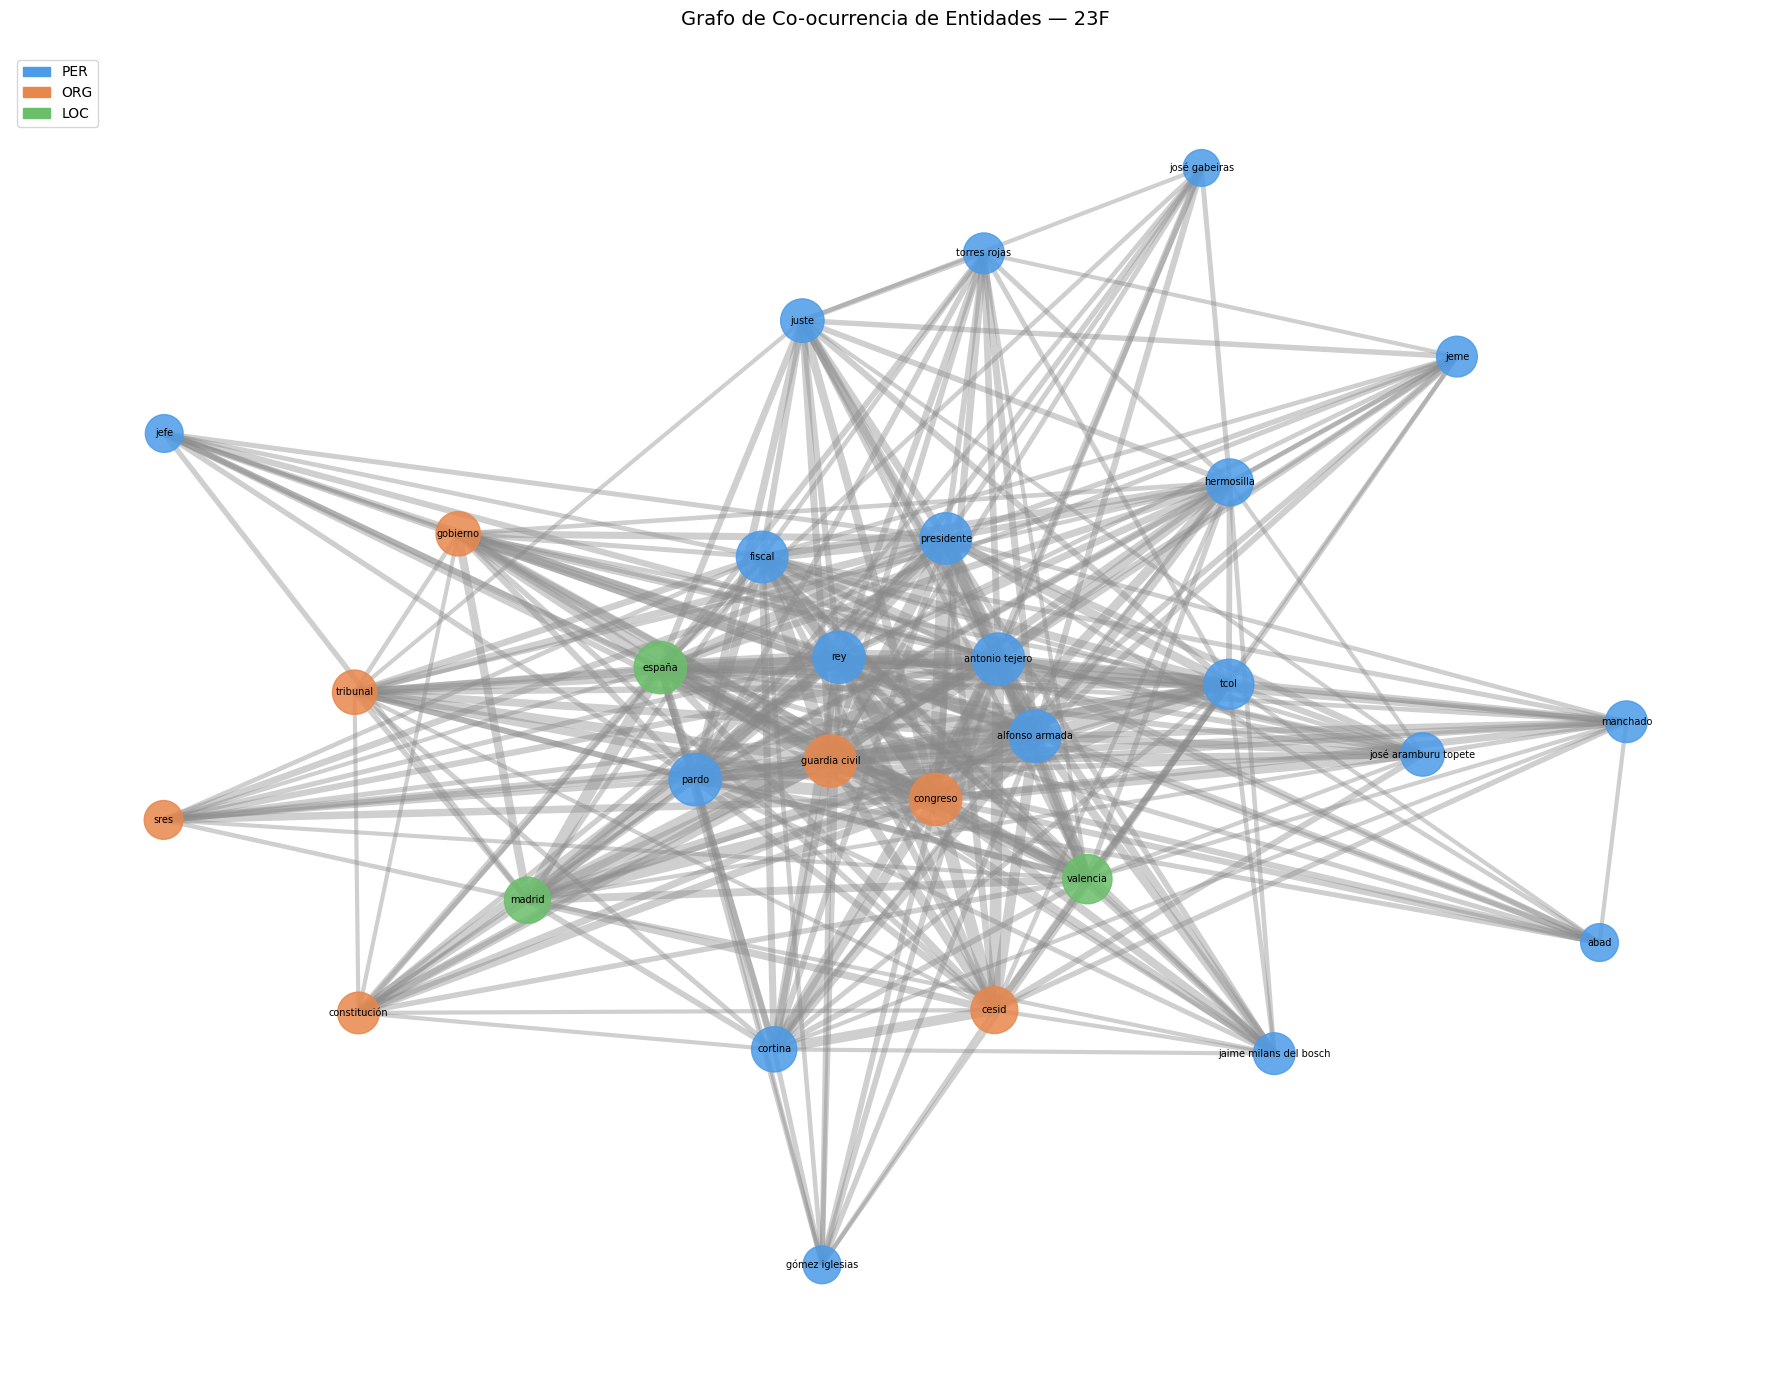

In [33]:
# Filtrar solo nodos con degree suficiente para no saturar el grafo
MIN_DEGREE = 10
subgraph_nodes = [n for n, d in G.degree() if d >= MIN_DEGREE]
G_sub = G.subgraph(subgraph_nodes)

plt.figure(figsize=(18, 14))

pos = nx.spring_layout(G_sub, weight="weight", seed=42, k=0.6)

node_colors = [G_sub.nodes[n]["color"] for n in G_sub.nodes()]
node_sizes  = [300 + G_sub.degree(n) * 40 for n in G_sub.nodes()]
edge_widths = [G_sub[u][v]["weight"] * 0.3 for u, v in G_sub.edges()]

nx.draw_networkx_nodes(G_sub, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85)
nx.draw_networkx_edges(G_sub, pos, width=edge_widths, alpha=0.4, edge_color="#888888")
nx.draw_networkx_labels(G_sub, pos, font_size=7, font_color="black")

# Leyenda
from matplotlib.patches import Patch
legend = [Patch(color=v, label=k) for k, v in TYPE_COLORS.items() if k != "UNK"]
plt.legend(handles=legend, loc="upper left", fontsize=10)

plt.title("Grafo de Co-ocurrencia de Entidades — 23F", fontsize=14, pad=20)
plt.axis("off")
plt.tight_layout()
plt.savefig("fase2_grafo_entidades.png", dpi=150, bbox_inches="tight")
plt.show()

### Grafo de Entidades Interactivo (PyVis)

In [ ]:
from pyvis.network import Network

net = Network(height="750px", width="100%", bgcolor="#1a1a2e", font_color="white")
net.barnes_hut(gravity=-8000, central_gravity=0.3, spring_length=150)

for node in G_sub.nodes(data=True):
    name, attrs = node
    size = 10 + G_sub.degree(name) * 2
    net.add_node(name, label=name, color=attrs["color"], size=size,
                 title=f"{attrs['type']}: {name}\nDegree: {G_sub.degree(name)}")

for u, v, data in G_sub.edges(data=True):
    net.add_edge(u, v, width=data["weight"] * 0.3,
                 title=f"Co-ocurrencias: {data['weight']}")

net.save_graph("fase2_grafo_interactivo.html")
print("Grafo interactivo guardado: fase2_grafo_interactivo.html")

## 8. Grafo de Jerarquía y Afiliación

### Creación de Grafo Dirigido

In [34]:
G_A = nx.DiGraph()

# Heredar los nodos del grafo base con sus atributos originales
for node, attrs in G.nodes(data=True):
    G_A.add_node(node, **attrs)

print(f"Grafo A inicializado con {G_A.number_of_nodes()} nodos de la Fase 2.")

Grafo A inicializado con 70 nodos de la Fase 2.


### Inferencia de Relaciones Sintacticas

In [35]:
def infer_relations_step(df_input, label_map):
    inferred_edges = []

    # Expansión de verbos de mando, comunicación y delegación
    mando_verbs = {
        'ordenar', 'mandar', 'disponer', 'dirigir', 'instruir', 'comandar',
        'transmitir', 'comunicar', 'notificar', 'exigir', 'encargar', 'solicitar'
    }
    # NUEVO: Sustantivos que articulan la cadena de mando militar
    mando_nouns = {'orden', 'órdenes', 'instrucción', 'instrucciones', 'mandato', 'mando', 'disposición', 'jefatura'}

    affiliation_triggers = {'del', 'de la', 'de los', 'perteneciente', 'miembro', 'integrante', 'destino', 'en'}

    for idx, row in df_input.iterrows():
        doc = row['spacy_doc']
        if not hasattr(doc, 'sents'):
            continue

        for sent in doc.sents:
            sent_ents = []
            for ent in sent.ents:
                if is_valid_entity(ent):
                    # Forzamos normalización canónica local
                    norm = canonicalize_entity(strip_rank_prefix(ent.text.strip().lower()))
                    etype = label_map.get(norm)
                    if etype:
                        sent_ents.append({'norm': norm, 'type': etype, 'ent_obj': ent})

            if len(sent_ents) < 2:
                continue

            persons = [e for e in sent_ents if e['type'] == 'PER']
            organizations = [e for e in sent_ents if e['type'] == 'ORG']

            # --- REGLA A: AFILIACIÓN ENRIQUECIDA (PER -> ORG) ---
            for p in persons:
                for o in organizations:
                    is_affiliated = False
                    p_ent, o_ent = p['ent_obj'], o['ent_obj']

                    for token in o_ent:
                        if token.head.dep_ in ('prep', 'mod') and token.head.head in p_ent:
                            is_affiliated = True
                            break

                    # Ventana léxica expandida a un límite de 10 tokens
                    if not is_affiliated:
                        p_start, p_end = p_ent.start, p_ent.end
                        o_start, o_end = o_ent.start, o_ent.end
                        if abs(o_start - p_end) <= 10 or abs(p_start - o_end) <= 10:
                            min_idx = min(p_end, o_end)
                            max_idx = max(p_start, o_start)
                            middle_text = doc[min_idx:max_idx].text.lower()
                            if any(trigger in middle_text for trigger in affiliation_triggers):
                                is_affiliated = True

                    if is_affiliated:
                        inferred_edges.append({
                            'source': p['norm'], 'target': o['norm'],
                            'type': 'affiliation', 'context': sent.text.strip()
                        })

            # --- REGLA B: JERARQUÍA OPTIMIZADA (PER -> PER) ---
            for i, p1 in enumerate(persons):
                for j, p2 in enumerate(persons):
                    if i == j: continue
                    p1_ent, p2_ent = p1['ent_obj'], p2['ent_obj']
                    is_hierarchy = False
                    commander, subordinate = None, None

                    # Estrategia B1: Dependencias sintácticas directas por Verbos
                    for token in sent:
                        if token.lemma_ in mando_verbs:
                            children = list(token.children)
                            subjs = [t for t in children if t.dep_ in ('nsubj', 'nsubjpass')]
                            objs = [t for t in children if t.dep_ in ('obj', 'iobj', 'obl')]

                            p1_is_subj = any(t in p1_ent for t in subjs)
                            p2_is_obj = any(t in p2_ent or (t.head in p2_ent) for t in objs)

                            if p1_is_subj and p2_is_obj:
                                is_hierarchy = True
                                commander, subordinate = p1['norm'], p2['norm']
                                break

                    # Estrategia B2: Análisis de estructuras nominales ("bajo las órdenes de X")
                    if not is_hierarchy:
                        for token in sent:
                            if token.text.lower() in mando_nouns:
                                emisor, receptor = None, None
                                for child in token.children:
                                    if child.dep_ == 'prep' and child.text.lower() == 'de':
                                        for gchild in child.children:
                                            if any(t in p1_ent for t in gchild.subtree) or gchild in p1_ent:
                                                emisor = p1['norm']
                                    if child.dep_ == 'prep' and child.text.lower() in ('a', 'para'):
                                        for gchild in child.children:
                                            if any(t in p2_ent for t in gchild.subtree) or gchild in p2_ent:
                                                receptor = p2['norm']

                                if emisor and receptor:
                                    is_hierarchy = True
                                    commander, subordinate = emisor, receptor
                                    break

                    # Estrategia B3: Ventana léxica extendida a 12 tokens con marcadores explícitos
                    if not is_hierarchy:
                        p1_start, p1_end = p1_ent.start, p1_ent.end
                        p2_start, p2_end = p2_ent.start, p2_ent.end

                        if abs(p1_start - p2_end) <= 12:
                            min_idx = min(p1_end, p2_end)
                            max_idx = max(p1_start, p2_start)
                            middle_text = doc[min_idx:max_idx].text.lower()

                            if 'órdenes de' in middle_text or 'mando de' in middle_text:
                                is_hierarchy = True
                                if p1_start < p2_start:
                                    commander, subordinate = p2['norm'], p1['norm']
                                else:
                                    commander, subordinate = p1['norm'], p2['norm']

                    if is_hierarchy and commander and subordinate:
                        inferred_edges.append({
                            'source': commander, 'target': subordinate,
                            'type': 'hierarchy', 'context': sent.text.strip()
                        })

    return pd.DataFrame(inferred_edges)

### Procesamiento y Depuración de Relaciones Detectadas

In [36]:
# Ejecutar inferencia usando el mapa de etiquetas resuelto en la Fase 1
df_raw_relations = infer_relations_step(df, resolved_labels)

# Limpiar posibles duplicados idénticos en la misma oración exacta
df_raw_relations = df_raw_relations.drop_duplicates(subset=['source', 'target', 'type', 'context'])

# Agrupar para obtener el peso de la relación por frecuencia
df_relations_weighted = (
    df_raw_relations.groupby(['source', 'target', 'type'])
    .size()
    .reset_index(name='weight')
)

print(f"Total de relaciones inferidas (menciones únicas): {len(df_raw_relations)}")
print(f"Relaciones únicas consolidadas: {len(df_relations_weighted)}")
print("\nDesglose por tipo de arco:")
print(df_relations_weighted['type'].value_counts())

Total de relaciones inferidas (menciones únicas): 637
Relaciones únicas consolidadas: 493

Desglose por tipo de arco:
type
affiliation    470
hierarchy       23
Name: count, dtype: int64


### Agregar de Arcos en Grafo Aumentado

In [37]:
for _, row in df_relations_weighted.iterrows():
    u, v, r_type, w = row['source'], row['target'], row['type'], row['weight']

    # Asegurar que los nodos existan (por si se filtraron previamente por bajo degree)
    if not G_A.has_node(u):
        G_A.add_node(u, type=resolved_labels.get(u, "UNK"), color=TYPE_COLORS.get(resolved_labels.get(u, "UNK"), "#AAAAAA"))
    if not G_A.has_node(v):
        G_A.add_node(v, type=resolved_labels.get(v, "UNK"), color=TYPE_COLORS.get(resolved_labels.get(v, "UNK"), "#AAAAAA"))

    if r_type == 'hierarchy':
        # Arco dirigido: Mando -> Subordinado
        G_A.add_edge(u, v, relation=r_type, weight=w)
    elif r_type == 'affiliation':
        # Arco bidireccional para representar pertenencia mutua institucional
        G_A.add_edge(u, v, relation=r_type, weight=w)
        G_A.add_edge(v, u, relation=r_type, weight=w)

print(f"Grafo A Final -> Nodos: {G_A.number_of_nodes()} | Arcos Dirigidos: {G_A.number_of_edges()}")

Grafo A Final -> Nodos: 504 | Arcos Dirigidos: 963


### Revision de Calidad y Exportacion

In [38]:
print("=" * 60)
print("MUESTRA DE RELACIONES INFERIDAS CON CONTEXTO REAL")
print("=" * 60)

# Ver una muestra aleatoria de las oraciones que dispararon los arcos
sample_size = min(8, len(df_raw_relations))
if sample_size > 0:
    for idx, r in df_raw_relations.sample(sample_size, random_state=42).iterrows():
        print(f"[{r['type'].upper()}] {r['source']} ➔ {r['target']}")
        print(f"Contexto: \"{r['context']}\"")
        print("-" * 60)

# Guardar los artefactos de la Fase 3
df_raw_relations.to_csv("fase3_relaciones_contexto.csv", index=False)
df_relations_weighted.to_csv("fase3_arcos_grafo_A.csv", index=False)
nx.write_gexf(G_A, "grafo_A_inferido.gexf") # Formato ideal para abrir en Gephi si lo necesitas

print("\nArtefactos guardados exitosamente. ¡Grafo A listo para la siguiente fase!")

MUESTRA DE RELACIONES INFERIDAS CON CONTEXTO REAL
[AFFILIATION] sanz arribas ➔ guardia civil
Contexto: "Intervinieron sucesivamente los siguientes defensores:  Comandante de la Guardia Civil Pardos Aldea, defensor del Capitán del mismo Cuerpo Lázaro Corthay.  Letrado Sr. Sanz Arribas, defensor de los Capitanes Bobis González de la Guardia Civil y Cid Fortea de Intendencia."
------------------------------------------------------------
[AFFILIATION] fernandez campos ➔ división acorazada
Contexto: "1  Seguidamente, aporta numerosos testimonios tendentes a demostrar, que a su defendido no se le menciona inicialmente en los hechos y así repasa diversas declaraciones de testigos participantes en la reunión de la División Acorazada, testimonio del General FERNANDEZ CAMPOS, Sres."
------------------------------------------------------------
[AFFILIATION] garcía almenta ➔ unidades
Contexto: "García Almenta ordenó retirar las Unidades porque la DAC iba a salir."
---------------------------------

### Visualizacion del Grafo de Afiliación y Jerarquía

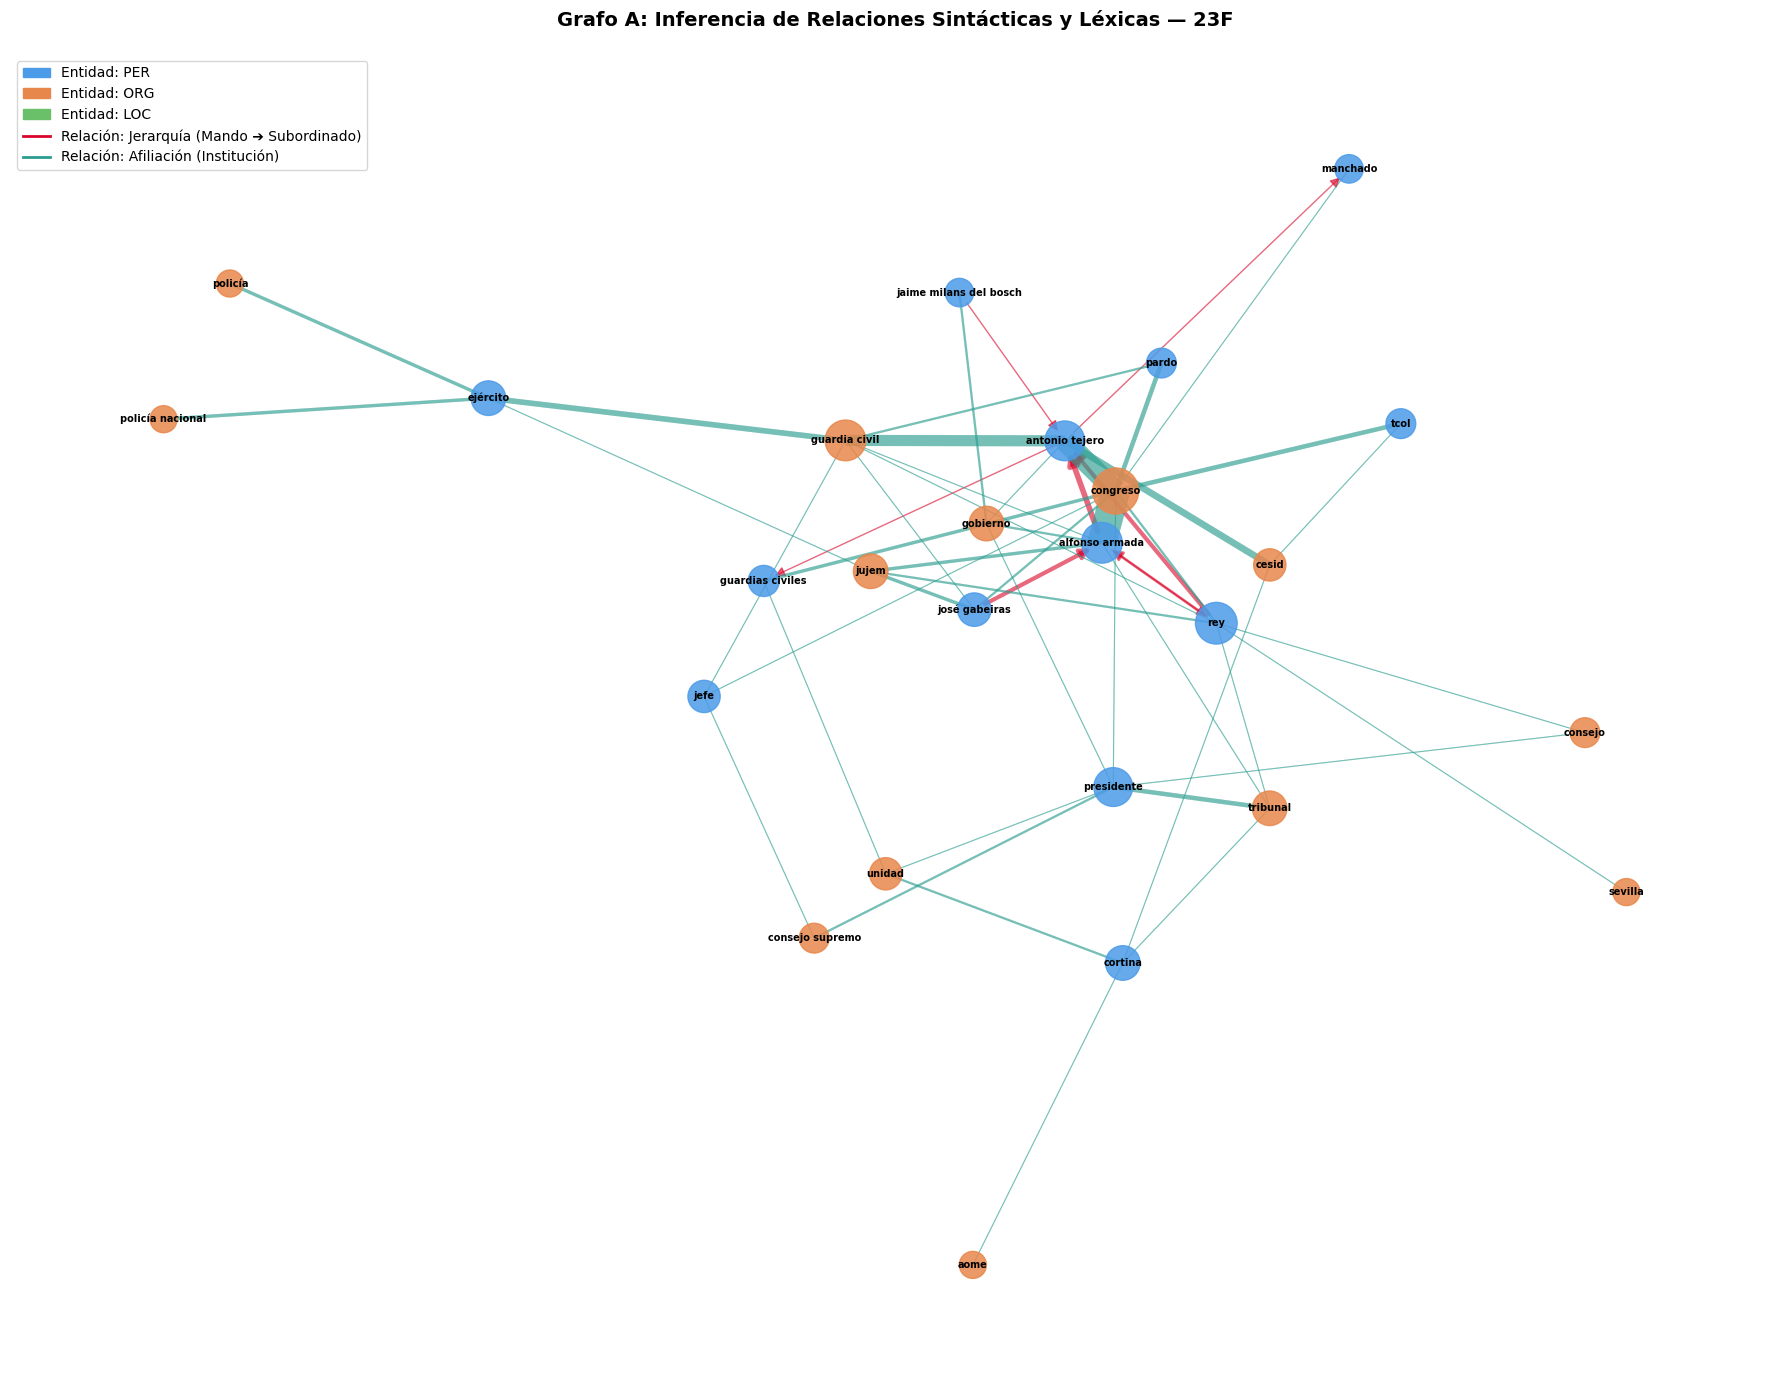

In [45]:
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 1. Configuración de filtros y subgrafo
MIN_DEGREE = 10

# Usamos G_A.degree() para asegurar consistencia si el grafo base G no está en memoria
subgraph_nodes = [n for n, d in G_A.degree() if d >= MIN_DEGREE]
G_A_sub = G_A.subgraph(subgraph_nodes)

plt.figure(figsize=(18, 14))

# 2. Cálculo de posiciones (Layout)
pos = nx.spring_layout(G_A_sub, weight="weight", seed=42, k=0.6)

# 3. Propiedades de los Nodos
node_colors = [G_A_sub.nodes[n]["color"] for n in G_A_sub.nodes()]
node_sizes  = [300 + G_A_sub.degree(n) * 40 for n in G_A_sub.nodes()]

# 4. Separación y Propiedades de los Arcos (Jerarquía vs Afiliación)
# Definimos los colores para cada tipo de relación
COLOR_JERARQUIA = "#D90429"  # Rojo vibrante
COLOR_AFILIACION = "#2A9D8F" # Verde azulado / Teal

hierarchy_edges = [(u, v) for u, v, d in G_A_sub.edges(data=True) if d.get('relation') == 'hierarchy']
affiliation_edges = [(u, v) for u, v, d in G_A_sub.edges(data=True) if d.get('relation') == 'affiliation']

hierarchy_widths = [G_A_sub[u][v]["weight"] * 1.0 for u, v in hierarchy_edges]
affiliation_widths = [G_A_sub[u][v]["weight"] * 0.8 for u, v in affiliation_edges]

# 5. Renderizado del Grafo
# Dibujar Nodos
nx.draw_networkx_nodes(G_A_sub, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85)

# Dibujar Arcos de Jerarquía (Con flechas de dirección explicitadas por ser un DiGraph)
if hierarchy_edges:
    nx.draw_networkx_edges(
        G_A_sub, pos, edgelist=hierarchy_edges, width=hierarchy_widths,
        alpha=0.6, edge_color=COLOR_JERARQUIA, arrows=True, arrowsize=15, arrowstyle="-|>"
    )

# Dibujar Arcos de Afiliación (Sin flechas o sutiles, al ser relaciones bidireccionales de pertenencia)
if affiliation_edges:
    nx.draw_networkx_edges(
        G_A_sub, pos, edgelist=affiliation_edges, width=affiliation_widths,
        alpha=0.4, edge_color=COLOR_AFILIACION, arrows=False
    )

# Dibujar Etiquetas de texto
nx.draw_networkx_labels(G_A_sub, pos, font_size=7, font_color="black", font_weight="bold")

# 6. Construcción de la Leyenda Completa (Nodos + Arcos)
legend_elements = []

# Añadir tipos de entidad (Nodos - Usando Patch)
for k, v in TYPE_COLORS.items():
    if k != "UNK":
        legend_elements.append(Patch(color=v, label=f"Entidad: {k}"))

# Añadir tipos de relación (Arcos - Usando Line2D para simular líneas del grafo)
legend_elements.append(Line2D([0], [0], color=COLOR_JERARQUIA, lw=2, label="Relación: Jerarquía (Mando ➔ Subordinado)"))
legend_elements.append(Line2D([0], [0], color=COLOR_AFILIACION, lw=2, label="Relación: Afiliación (Institución)"))

plt.legend(handles=legend_elements, loc="upper left", fontsize=10, frameon=True, facecolor="white")

# 7. Títulos y exportación final
plt.title("Grafo A: Inferencia de Relaciones Sintácticas y Léxicas — 23F", fontsize=14, pad=20, weight="bold")
plt.axis("off")
plt.tight_layout()
plt.savefig("fase3_grafo_A_inferido.png", dpi=150, bbox_inches="tight")
plt.show()

### Visualizacion del Grafo Interactivo de Afiliación y Jerarquía

In [ ]:
from pyvis.network import Network

# 1. Inicializar la red. Activamos directed=True para permitir las flechas de la jerarquía
net = Network(height="750px", width="100%", bgcolor="#1a1a2e", font_color="white", directed=True)
net.barnes_hut(gravity=-8000, central_gravity=0.3, spring_length=150)

# Colores para los arcos según su tipo de relación (consistentes con la visualización de Matplotlib)
COLOR_JERARQUIA = "#D90429"   # Rojo vibrante para Mando ➔ Subordinado
COLOR_AFILIACION = "#2A9D8F"  # Teal / Verde azulado para Pertenencia Institucional

# 2. Inyección dinámica de Nodos desde G_A_sub
for node in G_A_sub.nodes(data=True):
    name, attrs = node

    # Calculamos el tamaño basándonos en el grado de conexiones real dentro del Grafo A
    degree_A = G_A_sub.degree(name)
    size = 10 + degree_A * 2

    net.add_node(
        name,
        label=name,
        color=attrs["color"],
        size=size,
        title=f"Entidad ({attrs['type']}): {name}\nConexiones totales (Grafo A): {degree_A}"
    )

# 3. Inyección dinámica de Arcos con propiedades condicionales
for u, v, data in G_A_sub.edges(data=True):
    rel_type = data.get('relation', 'desconocida')
    weight = data.get('weight', 1)

    # Configurar el estilo visual de acuerdo al tipo de relación inferida
    if rel_type == 'hierarchy':
        edge_color = COLOR_JERARQUIA
        arrow_style = "to"  # Fuerza la flecha orientada hacia el subordinado
        edge_title = f"Relación: Jerarquía Militar (Peso: {weight})"
    else:
        # 'affiliation'
        edge_color = COLOR_AFILIACION
        arrow_style = ""    # Sin flecha visible para mantener la estética bidireccional institucional
        edge_title = f"Relación: Afiliación Institucional (Peso: {weight})"

    net.add_edge(
        u, v,
        width=weight * 0.5,       # Grosor proporcional al peso de la relación
        color=edge_color,
        arrows=arrow_style,
        title=edge_title
    )

# 4. Guardar y exportar el nuevo HTML de la Fase 3
net.save_graph("fase3_grafo_A_interactivo.html")
print("Grafo interactivo de la Fase 3 guardado: fase3_grafo_A_interactivo.html")